# Latent Transition Model — Visual Experiments

> **Goal:** Build intuition for action-conditioned latent dynamics, local linearization, rollout error, multi-step objectives, and manifold drift.

## What we will explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Action conditioning** | What does a transition learn when action is omitted? |
| 2 | **Residual and local dynamics** | Where does a local linear approximation remain trustworthy? |
| 3 | **One-step vs rollout** | How can a tiny local error become a large trajectory error? |
| 4 | **Multi-step fitting** | How does the deployment horizon change the preferred transition? |
| 5 | **Manifold drift** | Why should predicted states be checked against latent support? |

**Linked theory:** [Latent Transition Model](../research/02-latent-transition-model.md)

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})

def rotation(angle):
    return np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle), np.cos(angle)],
    ])

---
## Experiment 1: Action is part of the transition

**Question:** What happens when a controllable system is modeled as $z_{t+1}=f(z_t)$ instead of $z_{t+1}=f(z_t,a_t)$?

We generate a one-dimensional controlled process. Two linear models receive the same data: one sees only the current state, while the other also sees the action.

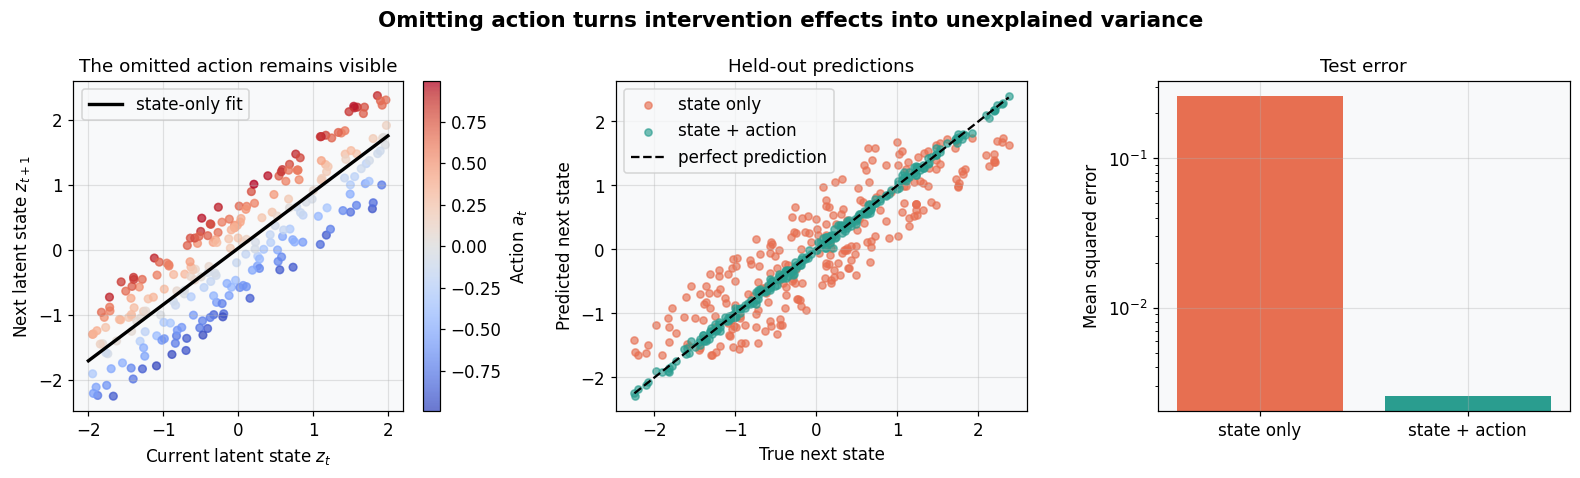

In [2]:
np.random.seed(1)
sample_count = 1000
state = np.random.uniform(-2.0, 2.0, sample_count)
action = np.random.uniform(-1.0, 1.0, sample_count)
next_state = 0.85 * state + 0.90 * action + 0.05 * np.random.randn(sample_count)

train = np.arange(0, 750)
test = np.arange(750, sample_count)

state_only_features = np.column_stack([np.ones(sample_count), state])
action_features = np.column_stack([np.ones(sample_count), state, action])
state_only_weights = np.linalg.lstsq(state_only_features[train], next_state[train], rcond=None)[0]
action_weights = np.linalg.lstsq(action_features[train], next_state[train], rcond=None)[0]

state_only_prediction = state_only_features[test] @ state_only_weights
action_prediction = action_features[test] @ action_weights
state_only_mse = np.mean((state_only_prediction - next_state[test]) ** 2)
action_mse = np.mean((action_prediction - next_state[test]) ** 2)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4))
fig.suptitle('Omitting action turns intervention effects into unexplained variance', fontsize=14, fontweight='bold')

scatter = axes[0].scatter(state[test], next_state[test], c=action[test], cmap='coolwarm', s=25, alpha=0.75)
state_grid = np.linspace(-2.0, 2.0, 100)
axes[0].plot(state_grid, state_only_weights[0] + state_only_weights[1] * state_grid, color='black', linewidth=2.2, label='state-only fit')
axes[0].set_title('The omitted action remains visible')
axes[0].set_xlabel('Current latent state $z_t$')
axes[0].set_ylabel('Next latent state $z_{t+1}$')
axes[0].legend()
fig.colorbar(scatter, ax=axes[0], label='Action $a_t$')

identity = [next_state[test].min(), next_state[test].max()]
axes[1].scatter(next_state[test], state_only_prediction, color='#e76f51', s=22, alpha=0.65, label='state only')
axes[1].scatter(next_state[test], action_prediction, color='#2a9d8f', s=22, alpha=0.65, label='state + action')
axes[1].plot(identity, identity, '--', color='black', linewidth=1.5, label='perfect prediction')
axes[1].set_title('Held-out predictions')
axes[1].set_xlabel('True next state')
axes[1].set_ylabel('Predicted next state')
axes[1].legend()

axes[2].bar(['state only', 'state + action'], [state_only_mse, action_mse], color=['#e76f51', '#2a9d8f'])
axes[2].set_title('Test error')
axes[2].set_ylabel('Mean squared error')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** At a fixed state, different actions lead to different next states. The state-only fit passes through the average response, while the action-conditioned fit nearly recovers the true transition.
2. **Why it looks this way:** Without $a_t$, the model estimates dynamics under the behavior-policy action distribution. Action effects appear as irreducible noise even though the environment is almost deterministic.
3. **Key takeaway:** A transition intended for control needs an explicit action contract; observational prediction alone does not support counterfactual action queries.

---
## Experiment 2: Residual dynamics and local linearization

**Question:** Why is a residual update natural at small timesteps, and why is a locally linear model only locally reliable?

A damped pendulum evolves through a small state increment. We compare its nonlinear residual field with the linearization $\sin(\theta)\approx\theta$ around the downward equilibrium.

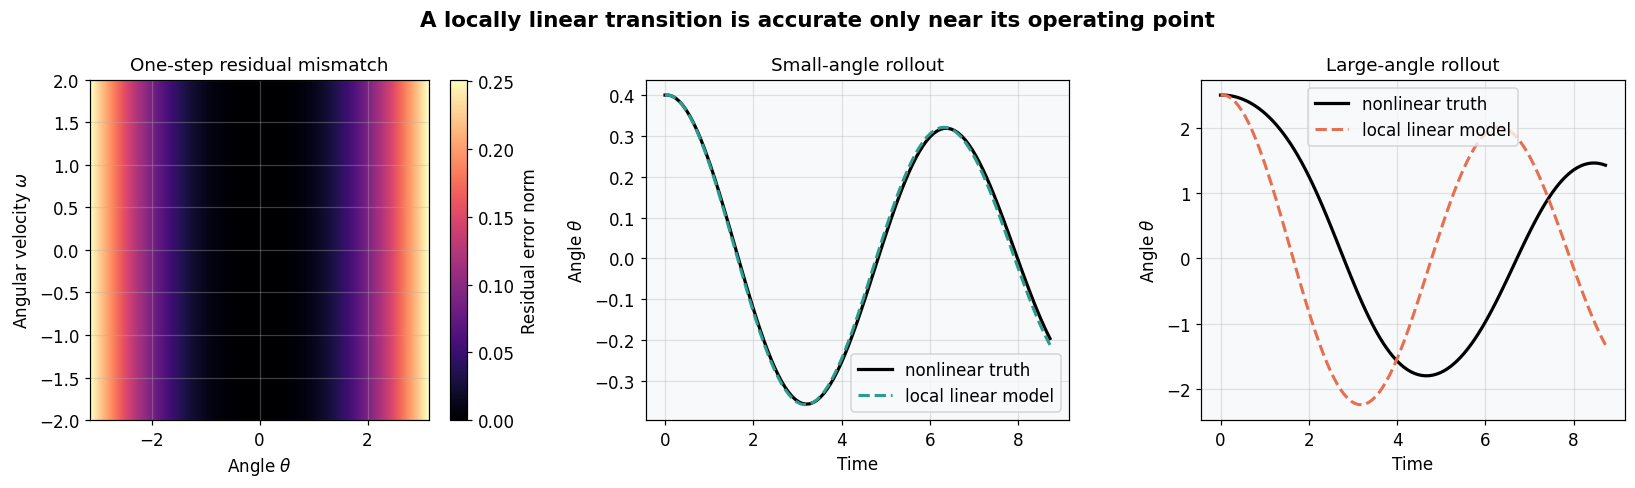

In [3]:
np.random.seed(2)
dt = 0.08
damping = 0.15

def pendulum_step(state_vector, linearized=False):
    theta, angular_velocity = state_vector
    restoring_force = theta if linearized else np.sin(theta)
    derivative = np.array([angular_velocity, -restoring_force - damping * angular_velocity])
    return state_vector + dt * derivative

theta_grid = np.linspace(-np.pi, np.pi, 151)
velocity_grid = np.linspace(-2.0, 2.0, 121)
theta_mesh, velocity_mesh = np.meshgrid(theta_grid, velocity_grid)
nonlinear_delta = np.stack([
    dt * velocity_mesh,
    dt * (-np.sin(theta_mesh) - damping * velocity_mesh),
], axis=-1)
linear_delta = np.stack([
    dt * velocity_mesh,
    dt * (-theta_mesh - damping * velocity_mesh),
], axis=-1)
local_error = np.linalg.norm(nonlinear_delta - linear_delta, axis=-1)

def rollout_pendulum(initial_state, steps, linearized=False):
    trajectory = np.empty((steps, 2))
    trajectory[0] = initial_state
    for index in range(steps - 1):
        trajectory[index + 1] = pendulum_step(trajectory[index], linearized=linearized)
    return trajectory

steps = 110
small_true = rollout_pendulum(np.array([0.4, 0.0]), steps)
small_linear = rollout_pendulum(np.array([0.4, 0.0]), steps, linearized=True)
large_true = rollout_pendulum(np.array([2.5, 0.0]), steps)
large_linear = rollout_pendulum(np.array([2.5, 0.0]), steps, linearized=True)
time = dt * np.arange(steps)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('A locally linear transition is accurate only near its operating point', fontsize=14, fontweight='bold')

heatmap = axes[0].imshow(local_error, origin='lower', aspect='auto', extent=[-np.pi, np.pi, -2.0, 2.0], cmap='magma')
axes[0].set_title('One-step residual mismatch')
axes[0].set_xlabel(r'Angle $\theta$')
axes[0].set_ylabel(r'Angular velocity $\omega$')
fig.colorbar(heatmap, ax=axes[0], label='Residual error norm')

axes[1].plot(time, small_true[:, 0], color='black', linewidth=2.1, label='nonlinear truth')
axes[1].plot(time, small_linear[:, 0], '--', color='#2a9d8f', linewidth=2.0, label='local linear model')
axes[1].set_title('Small-angle rollout')
axes[1].set_xlabel('Time')
axes[1].set_ylabel(r'Angle $\theta$')
axes[1].legend()

axes[2].plot(time, large_true[:, 0], color='black', linewidth=2.1, label='nonlinear truth')
axes[2].plot(time, large_linear[:, 0], '--', color='#e76f51', linewidth=2.0, label='local linear model')
axes[2].set_title('Large-angle rollout')
axes[2].set_xlabel('Time')
axes[2].set_ylabel(r'Angle $\theta$')
axes[2].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The one-step mismatch is small near $\theta=0$. Small-angle rollouts nearly overlap, whereas the large-angle linear rollout has the wrong period and amplitude evolution.
2. **Why it looks this way:** At a small timestep the transition is naturally written as identity plus a residual vector field. Replacing that field with its first-order approximation is accurate only inside a local neighborhood.
3. **Key takeaway:** Locally linear latent dynamics can simplify control, but their validity region must be measured rather than assumed across the whole state space.

---
## Experiment 3: One-step accuracy can hide rollout failure

**Question:** Can a model with a visually tiny one-step error still fail over a planning horizon?

The true latent state follows a slowly damped rotation. The learned transition has only a small angular and radial bias, but recursive application exposes the difference.

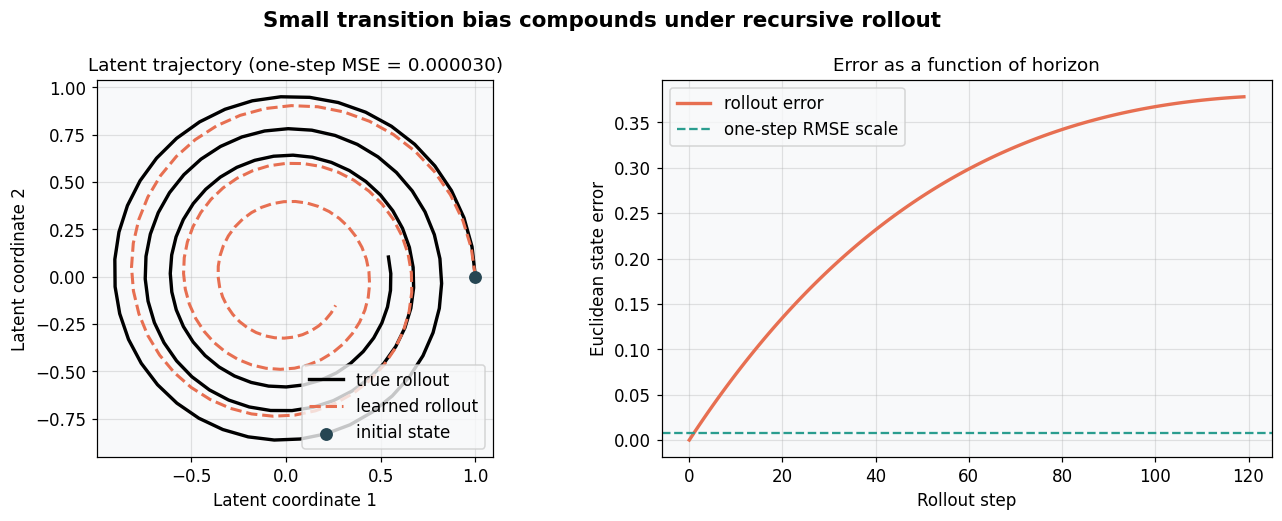

In [4]:
np.random.seed(3)
true_matrix = 0.995 * rotation(0.160)
learned_matrix = 0.990 * rotation(0.154)

angles = np.random.uniform(0.0, 2 * np.pi, 1500)
evaluation_states = np.column_stack([np.cos(angles), np.sin(angles)])
true_next = evaluation_states @ true_matrix.T
learned_next = evaluation_states @ learned_matrix.T
one_step_mse = np.mean((true_next - learned_next) ** 2)

horizon = 120
true_rollout = np.empty((horizon, 2))
learned_rollout = np.empty((horizon, 2))
true_rollout[0] = np.array([1.0, 0.0])
learned_rollout[0] = np.array([1.0, 0.0])
for index in range(horizon - 1):
    true_rollout[index + 1] = true_matrix @ true_rollout[index]
    learned_rollout[index + 1] = learned_matrix @ learned_rollout[index]

rollout_error = np.linalg.norm(true_rollout - learned_rollout, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
fig.suptitle('Small transition bias compounds under recursive rollout', fontsize=14, fontweight='bold')

axes[0].plot(true_rollout[:, 0], true_rollout[:, 1], color='black', linewidth=2.2, label='true rollout')
axes[0].plot(learned_rollout[:, 0], learned_rollout[:, 1], '--', color='#e76f51', linewidth=2.0, label='learned rollout')
axes[0].scatter([1.0], [0.0], color='#264653', s=55, zorder=3, label='initial state')
axes[0].set_title(f'Latent trajectory (one-step MSE = {one_step_mse:.6f})')
axes[0].set_xlabel('Latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].set_aspect('equal')
axes[0].legend()

axes[1].plot(np.arange(horizon), rollout_error, color='#e76f51', linewidth=2.2, label='rollout error')
axes[1].axhline(np.sqrt(2 * one_step_mse), color='#2a9d8f', linestyle='--', label='one-step RMSE scale')
axes[1].set_title('Error as a function of horizon')
axes[1].set_xlabel('Rollout step')
axes[1].set_ylabel('Euclidean state error')
axes[1].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The one-step MSE is very small, yet the learned spiral loses phase and radius relative to the true trajectory. Error grows far beyond its one-step scale.
2. **Why it looks this way:** Every predicted state becomes the next input. Angular bias accumulates as phase error, while radial bias compounds multiplicatively.
3. **Key takeaway:** Transition validation must report error by rollout horizon; one-step metrics alone do not establish planning reliability.

---
## Experiment 4: The objective selects a deployment horizon

**Question:** Why can one-step and multi-step objectives prefer different transition parameters?

The true system has a slow mode and a fast mode, but the model is deliberately underpowered: it must use one shared decay coefficient for both. The one-step objective emphasizes the initially large fast mode; the multi-step objective also sees the persistent slow mode.

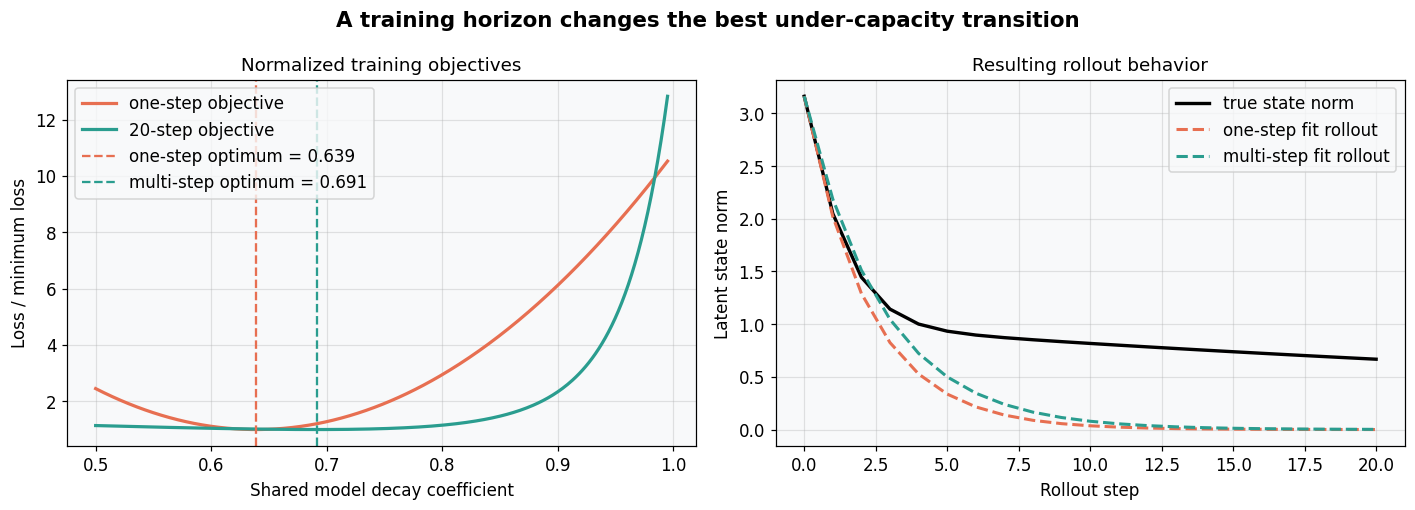

In [5]:
np.random.seed(4)
true_decay = np.array([0.98, 0.60])
initial_states = np.column_stack([
    np.random.normal(0.0, 1.0, 600),
    np.random.normal(0.0, 3.0, 600),
])
candidate_decay = np.linspace(0.50, 0.995, 350)
training_horizon = 20

true_sequences = np.empty((training_horizon + 1, len(initial_states), 2))
true_sequences[0] = initial_states
for step in range(training_horizon):
    true_sequences[step + 1] = true_sequences[step] * true_decay

one_step_loss = np.empty_like(candidate_decay)
multi_step_loss = np.empty_like(candidate_decay)
for index, decay in enumerate(candidate_decay):
    one_step_prediction = decay * true_sequences[0]
    one_step_loss[index] = np.mean((one_step_prediction - true_sequences[1]) ** 2)

    predicted = true_sequences[0].copy()
    accumulated_loss = 0.0
    for step in range(1, training_horizon + 1):
        predicted = decay * predicted
        accumulated_loss += np.mean((predicted - true_sequences[step]) ** 2)
    multi_step_loss[index] = accumulated_loss / training_horizon

one_step_decay = candidate_decay[np.argmin(one_step_loss)]
multi_step_decay = candidate_decay[np.argmin(multi_step_loss)]

example_initial = np.array([1.0, 3.0])
true_example = np.empty((training_horizon + 1, 2))
one_step_example = np.empty_like(true_example)
multi_step_example = np.empty_like(true_example)
true_example[0] = one_step_example[0] = multi_step_example[0] = example_initial
for step in range(training_horizon):
    true_example[step + 1] = true_example[step] * true_decay
    one_step_example[step + 1] = one_step_decay * one_step_example[step]
    multi_step_example[step + 1] = multi_step_decay * multi_step_example[step]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
fig.suptitle('A training horizon changes the best under-capacity transition', fontsize=14, fontweight='bold')

axes[0].plot(candidate_decay, one_step_loss / one_step_loss.min(), color='#e76f51', linewidth=2.1, label='one-step objective')
axes[0].plot(candidate_decay, multi_step_loss / multi_step_loss.min(), color='#2a9d8f', linewidth=2.1, label='20-step objective')
axes[0].axvline(one_step_decay, color='#e76f51', linestyle='--', label=f'one-step optimum = {one_step_decay:.3f}')
axes[0].axvline(multi_step_decay, color='#2a9d8f', linestyle='--', label=f'multi-step optimum = {multi_step_decay:.3f}')
axes[0].set_title('Normalized training objectives')
axes[0].set_xlabel('Shared model decay coefficient')
axes[0].set_ylabel('Loss / minimum loss')
axes[0].legend()

steps_axis = np.arange(training_horizon + 1)
axes[1].plot(steps_axis, np.linalg.norm(true_example, axis=1), color='black', linewidth=2.2, label='true state norm')
axes[1].plot(steps_axis, np.linalg.norm(one_step_example, axis=1), '--', color='#e76f51', linewidth=2.0, label='one-step fit rollout')
axes[1].plot(steps_axis, np.linalg.norm(multi_step_example, axis=1), '--', color='#2a9d8f', linewidth=2.0, label='multi-step fit rollout')
axes[1].set_title('Resulting rollout behavior')
axes[1].set_xlabel('Rollout step')
axes[1].set_ylabel('Latent state norm')
axes[1].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The one-step objective selects a stronger contraction because the large fast mode dominates the immediate error. The multi-step objective selects a slower decay that better preserves the mode still present later in the rollout.
2. **Why it looks this way:** With limited model capacity, an objective weights errors according to where and when they are measured. Multi-step consistency changes that weighting; it is not merely more copies of the same one-step loss.
3. **Key takeaway:** The training horizon is part of the model contract. It should match the horizon at which imagination, planning, or trajectory analysis will consume the transition.

---
## Experiment 5: Latent manifold drift

**Question:** What happens when a transition is locally plausible but repeatedly leaves the support produced by the encoder?

Assume valid encoded states lie on a unit circle. The true action-conditioned transition rotates along that manifold. A learned model has only a 1.5% radial expansion per step; a projected variant explicitly restores the support constraint.

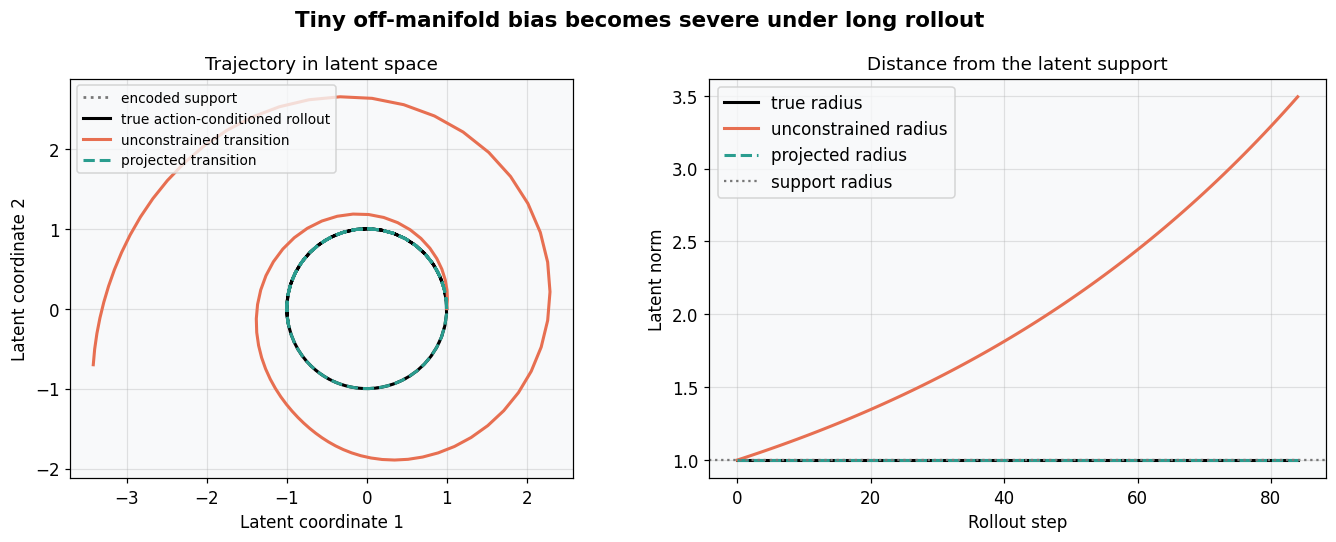

In [6]:
np.random.seed(5)
horizon = 85
actions = np.sin(np.linspace(0.0, 3.5 * np.pi, horizon - 1))
true_states = np.empty((horizon, 2))
drifting_states = np.empty((horizon, 2))
projected_states = np.empty((horizon, 2))
true_states[0] = drifting_states[0] = projected_states[0] = np.array([1.0, 0.0])

for step, action_value in enumerate(actions):
    angle = 0.11 + 0.055 * action_value
    true_states[step + 1] = rotation(angle) @ true_states[step]
    drifting_states[step + 1] = 1.015 * rotation(angle) @ drifting_states[step]
    projected_candidate = 1.015 * rotation(angle) @ projected_states[step]
    projected_states[step + 1] = projected_candidate / np.linalg.norm(projected_candidate)

circle_angle = np.linspace(0.0, 2 * np.pi, 300)
support_circle = np.column_stack([np.cos(circle_angle), np.sin(circle_angle)])

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))
fig.suptitle('Tiny off-manifold bias becomes severe under long rollout', fontsize=14, fontweight='bold')

axes[0].plot(support_circle[:, 0], support_circle[:, 1], ':', color='#777777', linewidth=1.8, label='encoded support')
axes[0].plot(true_states[:, 0], true_states[:, 1], color='black', linewidth=2.0, label='true action-conditioned rollout')
axes[0].plot(drifting_states[:, 0], drifting_states[:, 1], color='#e76f51', linewidth=2.0, label='unconstrained transition')
axes[0].plot(projected_states[:, 0], projected_states[:, 1], '--', color='#2a9d8f', linewidth=2.0, label='projected transition')
axes[0].set_title('Trajectory in latent space')
axes[0].set_xlabel('Latent coordinate 1')
axes[0].set_ylabel('Latent coordinate 2')
axes[0].set_aspect('equal')
axes[0].legend(loc='upper left', fontsize=9)

axes[1].plot(np.linalg.norm(true_states, axis=1), color='black', linewidth=2.0, label='true radius')
axes[1].plot(np.linalg.norm(drifting_states, axis=1), color='#e76f51', linewidth=2.0, label='unconstrained radius')
axes[1].plot(np.linalg.norm(projected_states, axis=1), '--', color='#2a9d8f', linewidth=2.0, label='projected radius')
axes[1].axhline(1.0, color='#777777', linestyle=':', label='support radius')
axes[1].set_title('Distance from the latent support')
axes[1].set_xlabel('Rollout step')
axes[1].set_ylabel('Latent norm')
axes[1].legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plots show:** The unconstrained transition initially follows the correct direction but spirals far outside the encoded unit-circle support. Projection removes radial drift while preserving the action-dependent angular motion.
2. **Why it looks this way:** A 1.5% radial error seems minor for one step but grows exponentially when the transition consumes its own predictions. Decoder and task heads would then be queried far outside their training distribution.
3. **Key takeaway:** Rollout diagnostics should track support, density, norm, or another geometry-aware validity measure in addition to prediction error.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Action conditioning | Omitting action learns behavior-policy averages rather than controllable dynamics. |
| 2. Local dynamics | Residual updates are natural at small timesteps, but linearization has a finite validity region. |
| 3. Rollout error | Tiny phase and scale biases can dominate long-horizon behavior. |
| 4. Multi-step fitting | The objective horizon changes which errors an under-capacity model prioritizes. |
| 5. Manifold drift | Predicted states need geometry-aware support checks during recursive rollout. |

### Connection to Latent-Anything

A transition plugin should expose its action schema, timestep, state geometry, training horizon, and validated rollout horizon. `Trajectory` diagnostics should distinguish encoded states from predicted states, report error by horizon, and measure whether imagined states remain inside the support understood by downstream decoders, reward heads, and planners.